### Avg heatmap for a network using 20 transition node communities data

Import packages

In [1]:
import sys
import pickle
sys.path.append('../analysis')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
from collections import deque
from MBN_Res_Constrn import MBN_RC
from ClusterTracking import SCTA

In [2]:
with open('../Mouse brain network/MouseBrainLib/mb_communities_dict.pickle', 'rb') as f:
    _x = pickle.load(f)

In [18]:
df_itr=pd.read_pickle('../../data/raw/FN/itr_data_fn.bz2')
df_nc=pd.read_pickle('../../data/raw/check_20/nc_fn_20.bz2')
df_lo=pd.read_pickle('../../data/raw/FN/l200.bz2')
df_toe = pd.read_pickle('../../data/raw/check_20/toe_fn_20.bz2')

In [147]:
df_nc=pd.read_pickle('../../data/raw/check_4/nc_bla_4-Copy1.bz2')

In [148]:
array_list = []
for p in range(1,5):
    
    

    if (df_nc.loc[p])[23].value_counts().size==1:
        main_cluster_index=0
    else:
        
        main_cluster_index = (df_nc.loc[p])[23].value_counts().index[1]
    #Read node community data for a transition
    matrix=df_nc.loc[p].values
    #Desired order i.e the sequence in which communities enter final cluster  in FN
    
    
    #the order in which community enters main cluster (may need to check)
    desired_keys = [3,6,4,2,0,7,1,5]
    #Arranged _x dictionary data in desired order
    _x_rearrange = {key: _x[key] for key in desired_keys}
    desired_order = [item for sublist in _x_rearrange.values() for item in sublist]
    rearranged_matrix = matrix[:, desired_order]
    #counting nodes in each community
    len_comm=[len(v) for v in _x_rearrange.values()]
    #Calculating time spent and sorting in descending order community wise
    
    time_spent=0
    ts=[]
    #c for comm. [0 to 7]
    com_count=0
    c=0
    last=len_comm[0]
    dict_sort={}
    
    for l in range(0,8):
        #l for iterating communities
        keys=[]
        values=[]
        for i in range(c,last):
            #i for iterating node
            
            for j in range(0,5000):
                #j for iterating timestep
                        
                if rearranged_matrix[j][i] == main_cluster_index:
                    time_spent+=1
                            
                else:
                    pass
                
            ts.append(time_spent)
            time_spent=0
    
        keys=list(range(c,last))
        values=ts[c:last]
        dict_0=dict(zip(keys,values))
        sorted_dict_dum = {k: v for k, v in sorted(dict_0.items(), key=lambda item: item[1],reverse=True)}
        dict_sort = dict_sort | sorted_dict_dum
        c=last
        com_count+=1
        if com_count<8:
            last=last+len_comm[com_count]
        else:
            break
    
    #rearranging matrix in the new order
    new_order=list(dict_sort.keys())
    final_matrix = rearranged_matrix[:, new_order]
    
    #np.place(final_matrix,final_matrix==0,np.nan)
    np.place(final_matrix,final_matrix!=main_cluster_index,-1)
    np.place(final_matrix,final_matrix==main_cluster_index,1)

    array_list.append(final_matrix)

stacked_matrices = np.stack(array_list, axis=0)
average_matrix = np.mean(stacked_matrices, axis=0)


    




In [142]:
final_matrix.shape

(5000, 426)

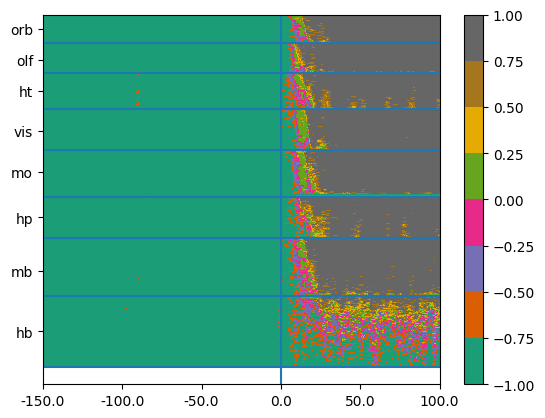

In [149]:
fig,axs = plt.subplots()
cax=axs.imshow(average_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs.axhline(_i)
axs.axvline(3000)
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs.set_xticks(xc_tick) 
axs.set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs.set_yticks(label_in)
axs.set_yticklabels(label)
fig.colorbar(cax,ax=axs)

In [117]:
fn_avg_matrix = average_matrix

In [150]:
bla_avg_matrix = average_matrix #17 iterations

In [125]:
peri_avg_matrix = average_matrix

In [130]:
enti_avg_matrix = average_matrix

In [135]:
pir_avg_matrix = average_matrix

In [139]:
re_avg_matrix=average_matrix #re matrix

In [144]:
orb_avg_matrix=average_matrix

In [151]:
keys=['fn','bla','peri','enti','pir','re','orb']
values=[fn_avg_matrix,bla_avg_matrix,peri_avg_matrix,enti_avg_matrix,pir_avg_matrix,re_avg_matrix,orb_avg_matrix]

In [153]:
import pickle
with open('avg_4.pkl', 'wb') as f: 
    pickle.dump(avg_mat_heat,f)

In [96]:
len(values)

6

In [152]:
avg_mat_heat=dict(zip(keys,values))

Plot these on Y axis

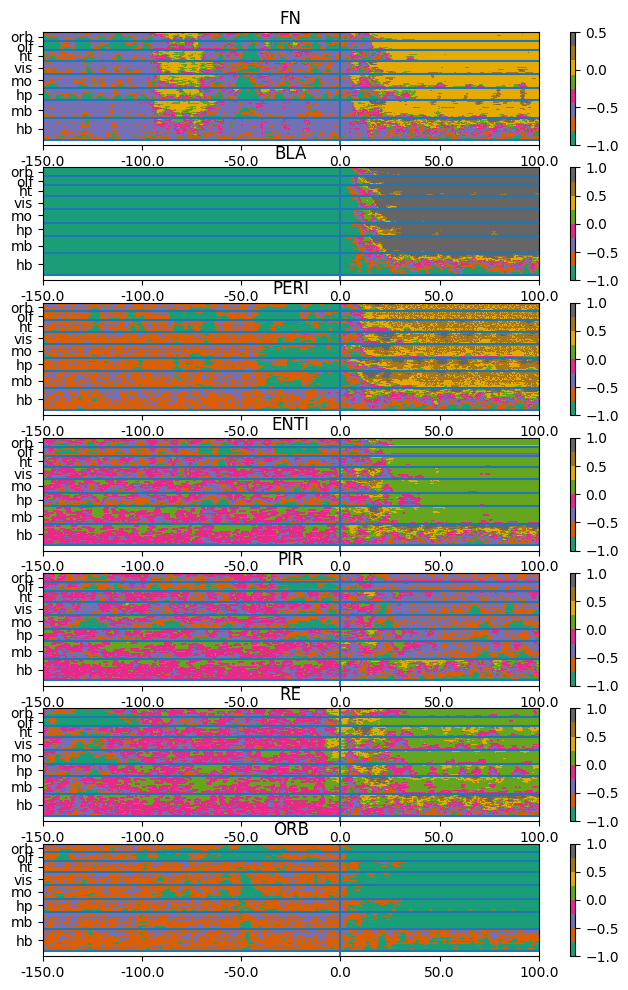

In [156]:
fig,axs = plt.subplots(7,1,figsize=(8, 12))
cax=axs[0].imshow(fn_avg_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[0].axhline(_i)
axs[0].axvline(3000)
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[0].set_title('FN')
axs[0].set_xticks(xc_tick) 
axs[0].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[0].set_yticks(label_in)
axs[0].set_yticklabels(label)
fig.colorbar(cax,ax=axs[0])

#bla
cax=axs[1].imshow(bla_avg_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[1].axhline(_i)
axs[1].axvline(3000)
axs[1].set_title('BLA')
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[1].set_xticks(xc_tick) 
axs[1].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[1].set_yticks(label_in)
axs[1].set_yticklabels(label)
fig.colorbar(cax,ax=axs[1])

#peri
cax=axs[2].imshow(peri_avg_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[2].axhline(_i)
axs[2].axvline(3000)
axs[2].set_title('PERI')
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[2].set_xticks(xc_tick) 
axs[2].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[2].set_yticks(label_in)
axs[2].set_yticklabels(label)
fig.colorbar(cax,ax=axs[2])

#enti
cax=axs[3].imshow(enti_avg_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[3].axhline(_i)
axs[3].axvline(3000)
axs[3].set_title('ENTI')
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[3].set_xticks(xc_tick) 
axs[3].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[3].set_yticks(label_in)
axs[3].set_yticklabels(label)
fig.colorbar(cax,ax=axs[3])


#pir
cax=axs[4].imshow(pir_avg_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[4].axhline(_i)
axs[4].axvline(3000)
axs[4].set_title('PIR')
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[4].set_xticks(xc_tick) 
axs[4].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[4].set_yticks(label_in)
axs[4].set_yticklabels(label)
fig.colorbar(cax,ax=axs[4])


#re
cax=axs[5].imshow(re_avg_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[5].axhline(_i)
axs[5].axvline(3000)
axs[5].set_title('RE')
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[5].set_xticks(xc_tick) 
axs[5].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[5].set_yticks(label_in)
axs[5].set_yticklabels(label)
fig.colorbar(cax,ax=axs[5])


#orb
cax=axs[6].imshow(orb_avg_matrix.T,cmap='Dark2',aspect='auto')
for _i in np.cumsum([v for v in len_comm]): 
    
    axs[6].axhline(_i)
axs[6].axvline(3000)
axs[6].set_title('ORB')
label=['orb','olf','ht','vis','mo','hp','mb','hb']
xc_tick=[0,1000,2000,3000,4000,5000]
axs[6].set_xticks(xc_tick) 
axs[6].set_xticklabels([(x - 3000)*0.05 for x in xc_tick])
label_in=[17,54,92,140,190,245,310,383]
axs[6].set_yticks(label_in)
axs[6].set_yticklabels(label)
fig.colorbar(cax,ax=axs[6])


plt.savefig('all_avg_hmap.png')